# imports

In [1]:
from pathlib import Path

import numpy as np
import polars as pl
from jaxtyping import Float
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# muutils
import muutils.tensor_info
from muutils.dbg import dbg_tensor

# attention-motifs
from attention_motifs.features.analysis import (
	null_stats,
	filter_data,
	normalize_data,
	pca_importance_table,
	aggregate_feature_stats,
	plot_importance_covariance,
)
from attention_motifs.features.plotting import (
	plot_embedding,
	apply_pca,
)

In [2]:
# magic autoreload
%load_ext autoreload
%autoreload 2

In [3]:
# numbers of rows to display
pl.Config.set_tbl_rows(10)
# colored muutils tensor info
muutils.tensor_info.DEFAULT_SETTINGS["colored"] = True
# base path
PATH_BASE: Path = Path("../data/features/")
PATH_FIGURES: Path = Path("figures/")

In [4]:
# raw data from file instead of regenerating
DATA_RAW = pl.read_ndjson(PATH_BASE / "raw-m8-p128-c101.jsonl")

# basic data inspection

In [5]:
# display(DATA_RAW)
# display(set(DATA_RAW.dtypes))
# display(DATA_RAW.head())
# display(DATA_RAW.describe())
# print(f"{DATA_RAW['activation.model'].unique() = }")
# for col in DATA_RAW.columns:
# 	if col.startswith("activation"):
# 		print(f"{col = }")
display(null_stats(DATA_RAW))

feature,missing_count,missing_frac
str,i64,f64
"""activation.layer""",0,0.0
"""activation.n_ctx""",0,0.0
"""activation.head""",0,0.0
"""feat.log.gram.col.hist.skewnes…",0,0.0
"""activation.model""",0,0.0
…,…,…
"""feat.log.gram.col.hist.median""",0,0.0
"""feat.log.gram.skew.hist.skewne…",0,0.0
"""feat.first_tok.linreg.r2""",0,0.0


# filter nans and certain models

In [6]:
# this will filter all-nan rows
DATA_FILTERED: pl.DataFrame = filter_data(
	DATA_RAW,
	# tinystories and small pythia models look very different in embedding space, so we get rid of them
	remove_models=["tiny-stories-1M", "pythia-14m"],
)
null_stats(DATA_FILTERED)

Removing 2 models: ['tiny-stories-1M', 'pythia-14m']
Removed 19456/214016 rows
Removing 2/94 feat.* columns due to zero variance or excessive missing values
feat.log.gram.row.hist.median                                μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] shape=194560 dtype=float64
feat.log.gram.col.hist.median                                μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] shape=194560 dtype=float64


feature,missing_count,missing_frac
str,i64,f64
"""activation.layer""",0,0.0
"""activation.n_ctx""",0,0.0
"""activation.head""",0,0.0
"""feat.log.gram.col.hist.skewnes…",0,0.0
"""activation.model""",0,0.0
…,…,…
"""feat.gram.skew.hist.variance""",0,0.0
"""feat.log.gram.skew.hist.skewne…",0,0.0
"""feat.first_tok.linreg.r2""",0,0.0


# scaling

In [7]:
FEATURE_COLS: list[str] = [
	col for col in DATA_FILTERED.columns if col.startswith("feat.")
]
DATA_SCALED: pl.DataFrame
_data_norms: pl.DataFrame
DATA_SCALED, _data_norms = normalize_data(DATA_FILTERED, FEATURE_COLS)
_data_norms.write_ndjson(PATH_BASE / "norms.jsonl")
DATA_SCALED.write_ndjson(PATH_BASE / "scaled.jsonl")
display(null_stats(DATA_SCALED))
META_COLS: list[str] = [
	col for col in DATA_SCALED.columns if col.startswith("activation.")
]

feature,missing_count,missing_frac
str,i64,f64
"""activation.layer""",0,0.0
"""activation.n_ctx""",0,0.0
"""activation.head""",0,0.0
"""feat.log.gram.col.hist.skewnes…",0,0.0
"""activation.model""",0,0.0
…,…,…
"""feat.gram.skew.hist.variance""",0,0.0
"""feat.log.gram.skew.hist.skewne…",0,0.0
"""feat.first_tok.linreg.r2""",0,0.0


In [8]:
# plot_correlation_matrix(
# 	DATA_SCALED,
# 	FEATURE_COLS,
# 	sort_by="var",
# )

# PCA

/home/miv/projects/attn/attention-motifs/attention_motifs/features/plotting.py:149: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


Number of components: 16
Total explained variance: 0.9230
Components needed for 80% variance: 7
Components needed for 90% variance: 14


[ <ipykernel>:6 ] PCA_DATA: μ=0.00 σ=2.30 x̃=-0.07 R=[-16.89,28.78] ℙ=|  █    | shape=(194560,16) dtype=float64
[ <ipykernel>:7 ] PCA_OBJ.components_: μ=0.00 σ=0.10 x̃=-0.00 R=[-0.37,0.52] ℙ=| ▁█▅▁  | shape=(16,92) dtype=float64


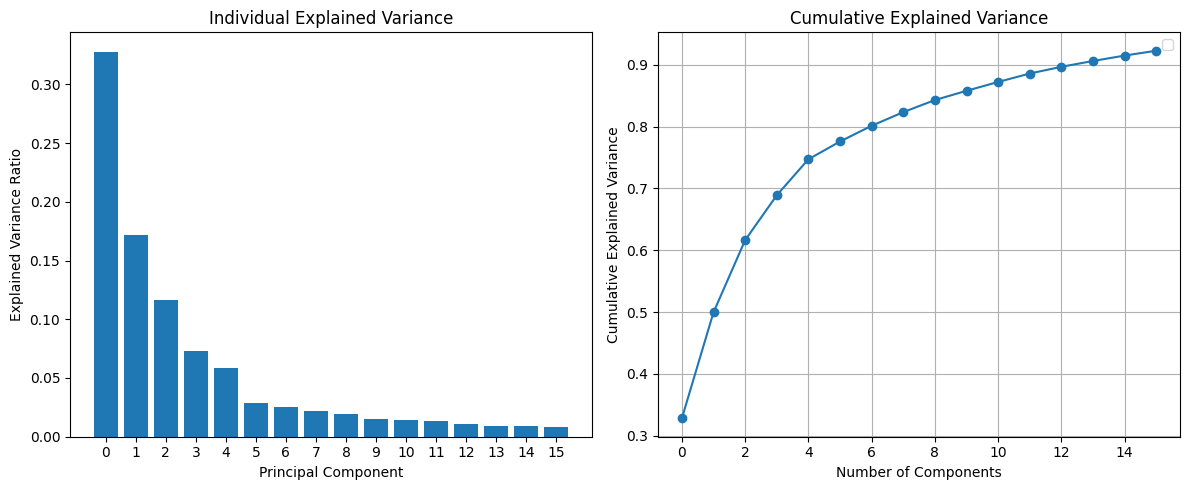

In [9]:
# dbg_tensor(DATA_SCALED[FEATURE_COLS].to_numpy())
PCA_DATA: np.ndarray
PCA_OBJ: PCA
PCA_DATA, PCA_OBJ = apply_pca(DATA_SCALED, n_components=16, feature_cols=FEATURE_COLS)
plt.savefig(PATH_FIGURES / "pca-variance.pdf", bbox_inches="tight", pad_inches=0.01)
dbg_tensor(PCA_DATA)
dbg_tensor(PCA_OBJ.components_)

# pca and meta in one dataframe
DF_PCA: pl.DataFrame = pl.concat(
	[
		# metadata -- "activation.*"
		DATA_SCALED[META_COLS],
		# pca cols
		pl.DataFrame(PCA_DATA, schema=[f"pc.{i}" for i in range(PCA_DATA.shape[1])]),
	],
	how="horizontal",
)
DF_PCA.write_ndjson(PATH_BASE / "pca.jsonl")

In [10]:
df_importance: pl.DataFrame = pca_importance_table(
	PCA_OBJ,
	feature_names=FEATURE_COLS,
)
df_importance.sort(pl.col("PC0").abs(), descending=True)

feature,PC0,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,abs_mean,abs_max,abs_var,var_weighted
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""feat.log.gram.col.hist.linreg.…",0.175145,-0.028945,-0.010196,0.033493,-0.032688,-0.013156,0.032888,0.02886,0.034006,-0.016511,-0.045896,-0.014257,0.040183,-0.009312,-0.121313,0.027505,0.041522,0.175145,0.001826,0.073351
"""feat.log.gram.col.hist.linreg.…",-0.173638,0.037772,-0.011184,-0.033725,0.045994,0.001506,-0.05119,-0.033105,-0.011323,0.029667,0.06524,0.019701,-0.037635,-0.029268,0.107193,0.000915,0.043066,0.173638,0.001776,0.075433
"""feat.log.gram.col.hist.rms""",-0.171375,0.039043,0.039099,-0.015268,0.015728,0.003857,0.008708,-0.042172,-0.054364,0.021774,0.043257,0.011258,-0.015754,0.029835,0.156731,-0.086863,0.047193,0.171375,0.002363,0.075422
"""feat.log.gram.col.hist.linreg.…",0.170928,-0.04129,0.024326,0.031691,-0.05355,0.00693,0.058974,0.032195,0.00996,-0.033297,-0.08507,-0.017289,0.022267,0.06931,-0.117869,-0.001096,0.048503,0.170928,0.00189,0.077891
"""feat.log.gram.col.hist.varianc…",-0.170316,0.042038,0.042,-0.011483,0.0132,0.000083,0.014496,-0.045648,-0.056277,0.023803,0.044357,0.011625,-0.010045,0.029561,0.16131,-0.095991,0.048265,0.170316,0.002495,0.075756
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""feat.first_tok.entropy""",-0.004029,-0.158586,-0.013536,-0.05378,0.261133,0.056702,0.043948,-0.071943,0.00566,0.054096,0.079139,-0.120428,0.035218,-0.236607,0.097639,0.023249,0.082231,0.261133,0.005599,0.060917
"""feat.gram.row.hist.linreg.inte…",-0.002972,0.199096,-0.04057,0.024529,-0.154572,0.247228,-0.080188,-0.012783,-0.023325,-0.05814,-0.019247,0.04672,0.040082,-0.045092,0.041901,-0.024183,0.066289,0.247228,0.004728,0.06376
"""feat.first_tok.kurtosis""",-0.00257,0.159032,-0.017511,-0.024788,-0.216914,-0.037234,0.029716,0.029418,0.117138,-0.108424,-0.064088,0.034787,0.031641,0.054875,-0.07015,-0.014411,0.063294,0.216914,0.003265,0.053987


In [11]:
display(aggregate_feature_stats(df_importance, side=1).sort("max", descending=True))

token,mean,min,max,median
str,f64,f64,f64,f64
"""gram""",0.07596,0.035896,0.137886,0.071903
"""first_tok""",0.084421,0.047354,0.136049,0.074226
"""diag""",0.094017,0.066443,0.1359,0.084697
"""log""",0.066635,0.041522,0.124082,0.060457


/home/miv/projects/attn/attention-motifs/attention_motifs/features/analysis.py:419: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/home/miv/projects/attn/attention-motifs/attention_motifs/features/analysis.py:419: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


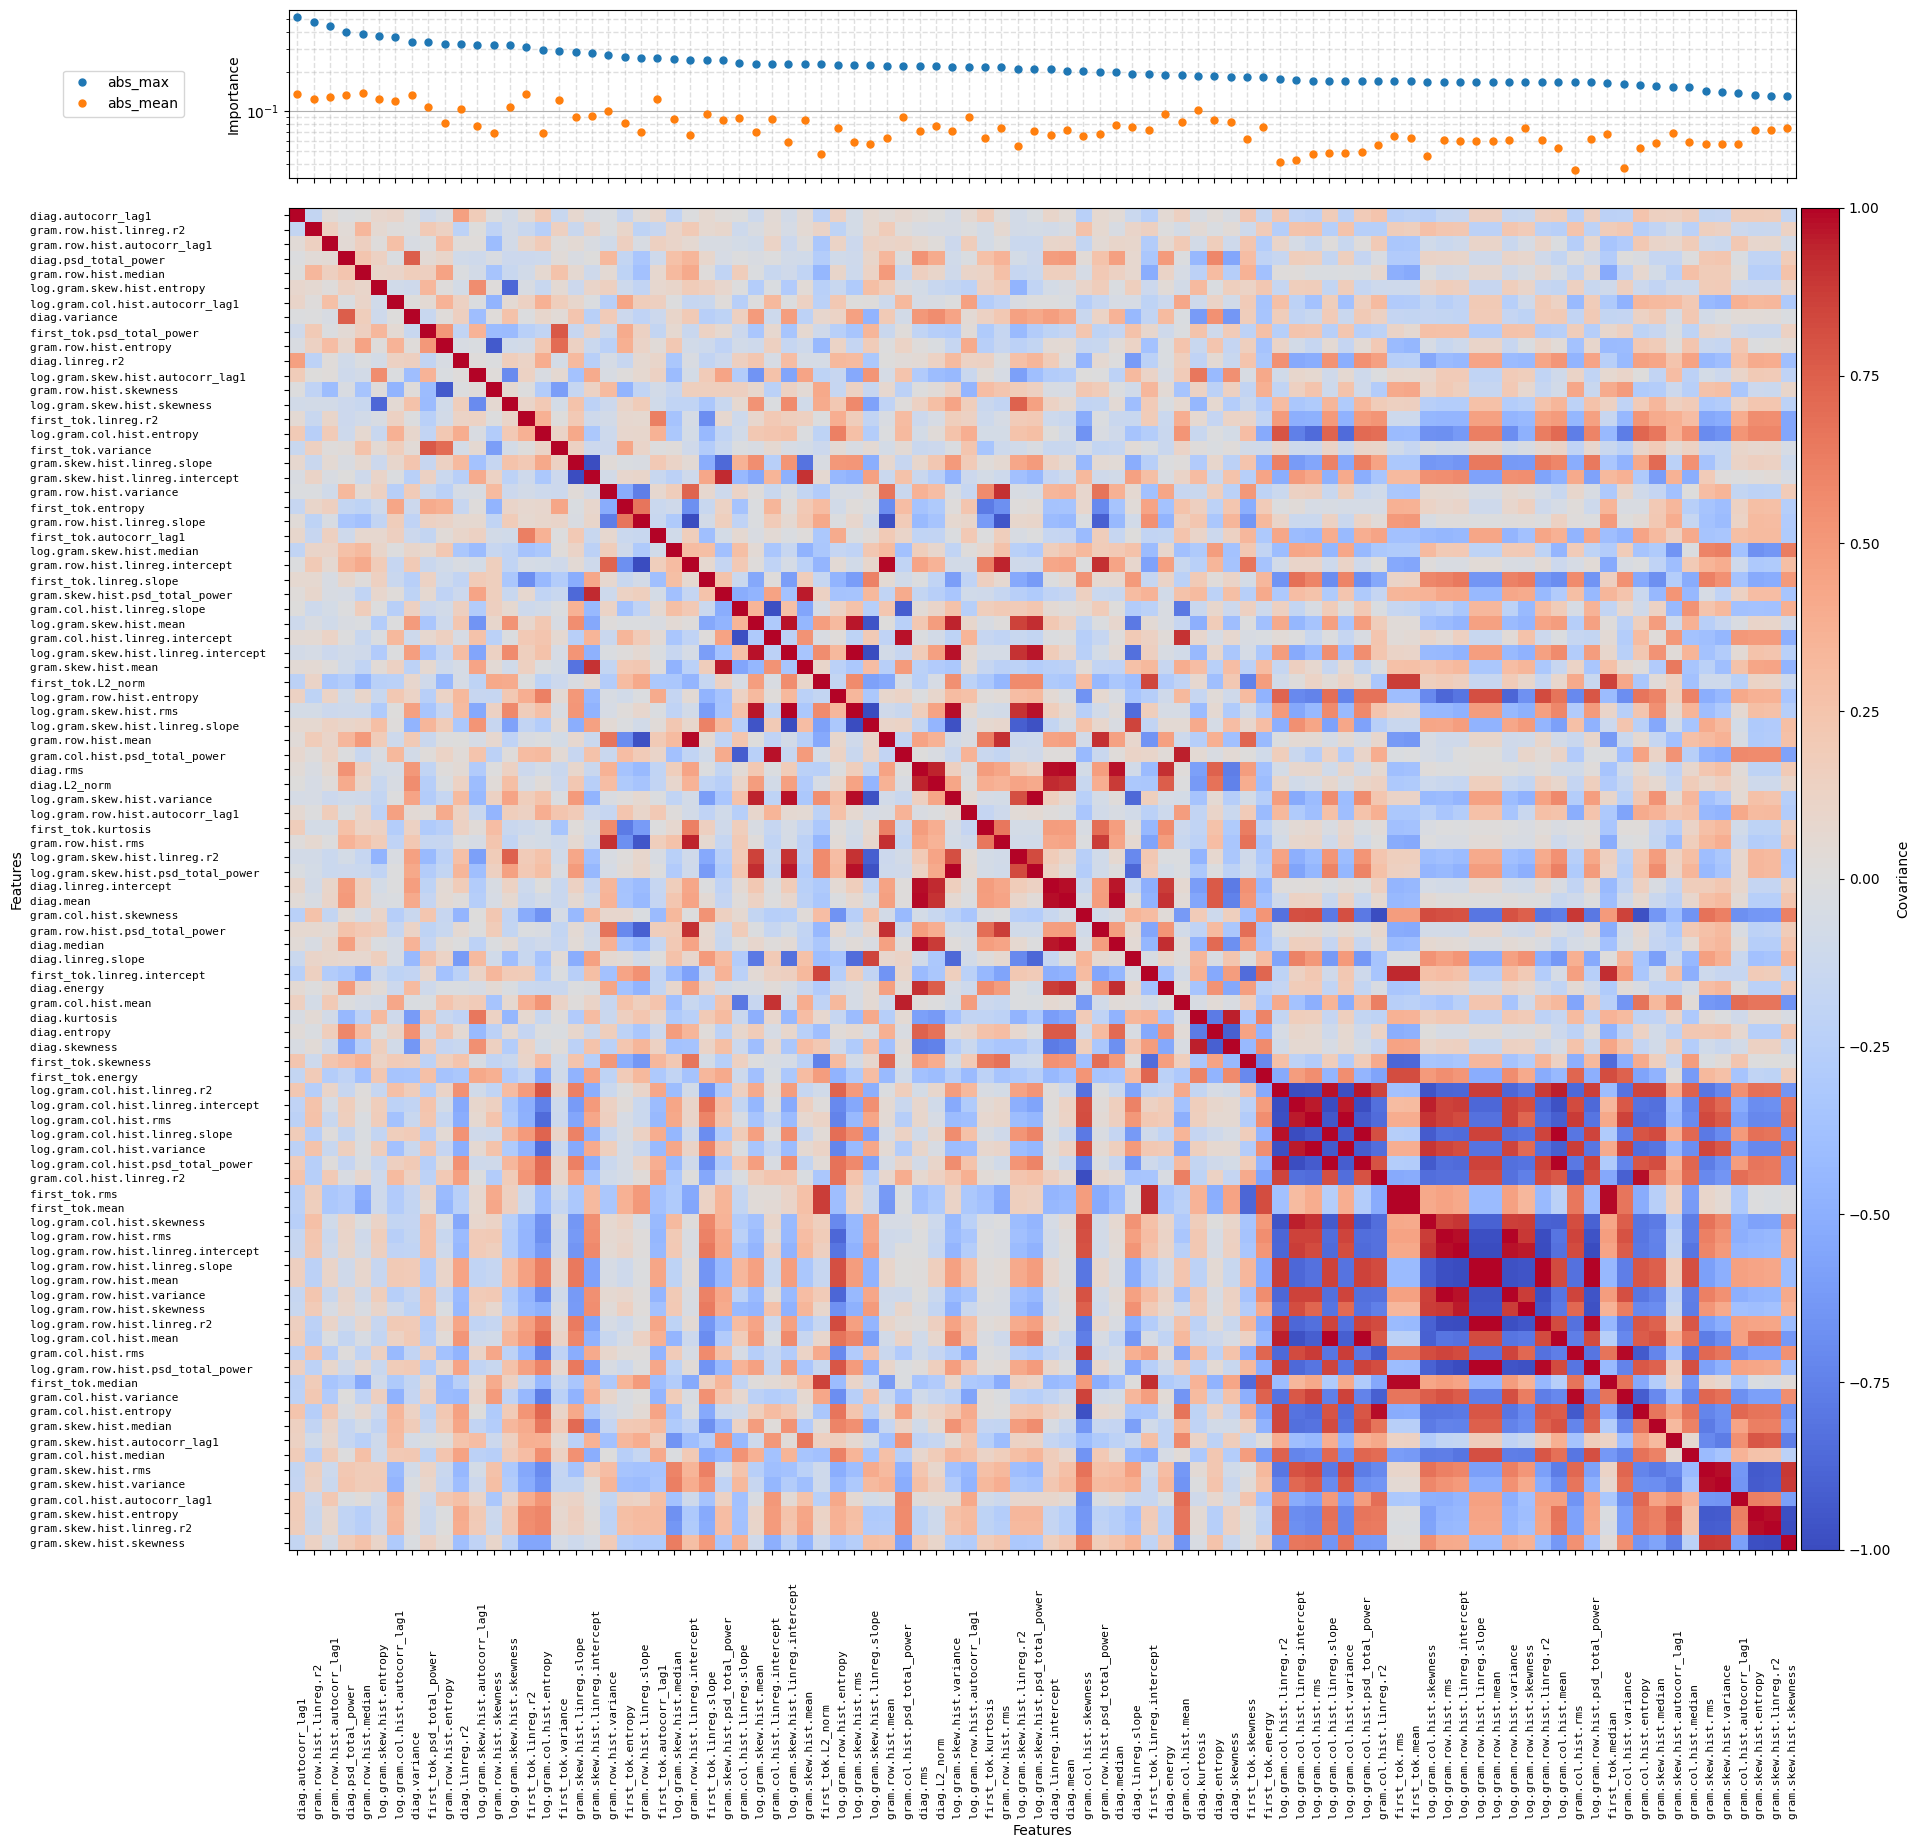

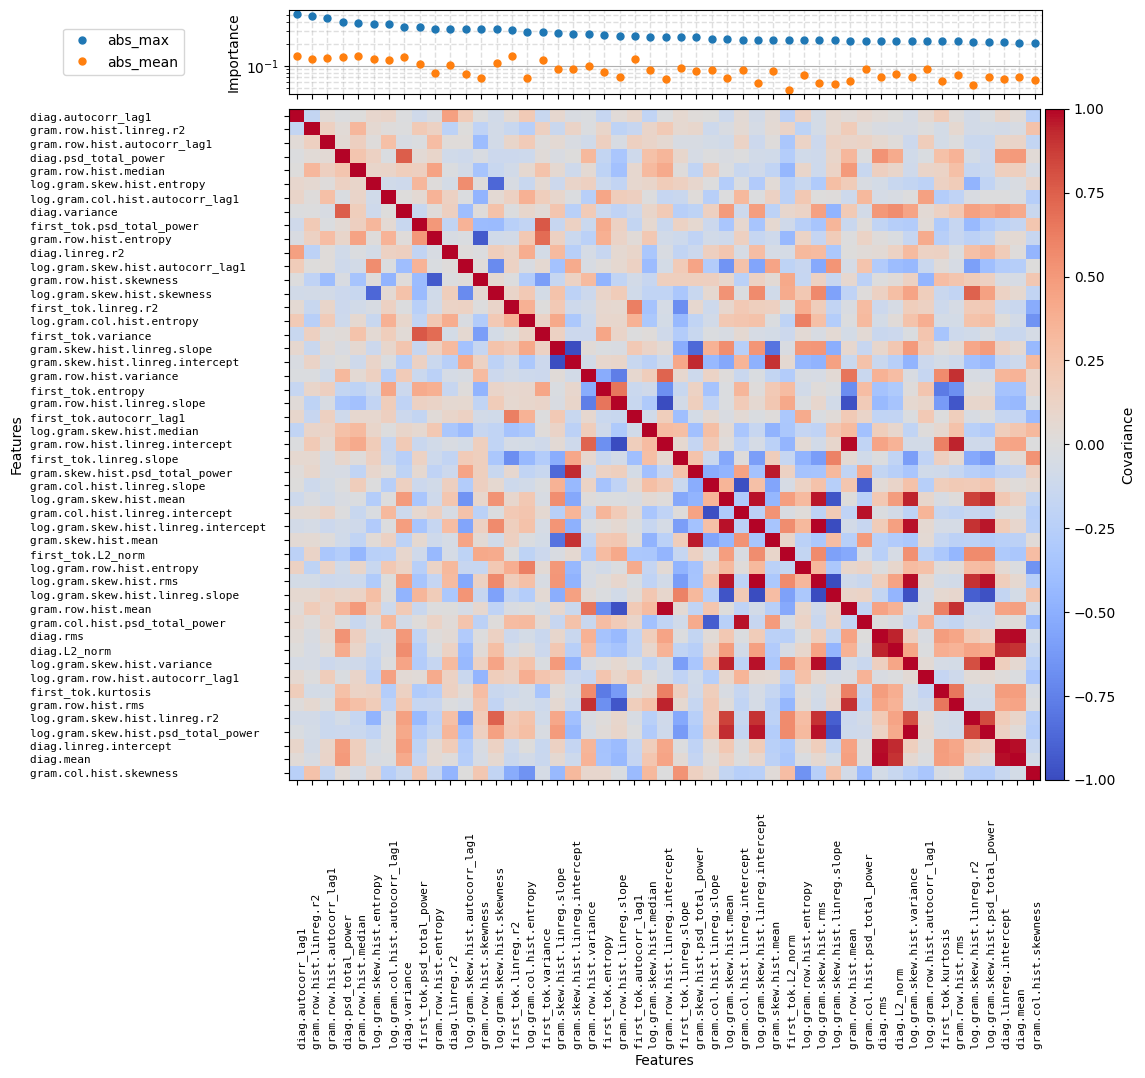

In [12]:
COV_FEATS: list[str]
COV_MAT: Float[np.ndarray, "n_features n_features"]

# full
COV_FEATS, COV_MAT = plot_importance_covariance(
	DATA_SCALED,
	df_importance,
	# feature_order=sorted(FEATURE_COLS, key=lambda x: x.split(".")[-1]),
	metrics=["abs_max", "abs_mean"],
	descending=True,
	cmap="coolwarm",
	figsize=(20, 20),
	tick_pad=100,
	imp_legend_align=-0.15,
)
plt.savefig(PATH_FIGURES / "feature-cov-full.pdf", bbox_inches="tight", pad_inches=0.01)

# reduced
plot_importance_covariance(
	DATA_SCALED,
	df_importance,
	# feature_order=sorted(FEATURE_COLS, key=lambda x: x.split(".")[-1]),
	metrics=["abs_max", "abs_mean"],
	descending=True,
	cmap="coolwarm",
	figsize=(10, 10),
	tick_pad=100,
	importance_threshold=0.2,
)
plt.savefig(
	PATH_FIGURES / "feature-cov-reduced.pdf", bbox_inches="tight", pad_inches=0.01
)

In [13]:
# from attention_motifs.features.analysis import print_covariance_groups
# print_covariance_groups(
# 	cov_feats=COV_FEATS,
# 	cov_mat=COV_MAT,
# 	df_importance=df_importance,
# 	threshold=0.9,
# )

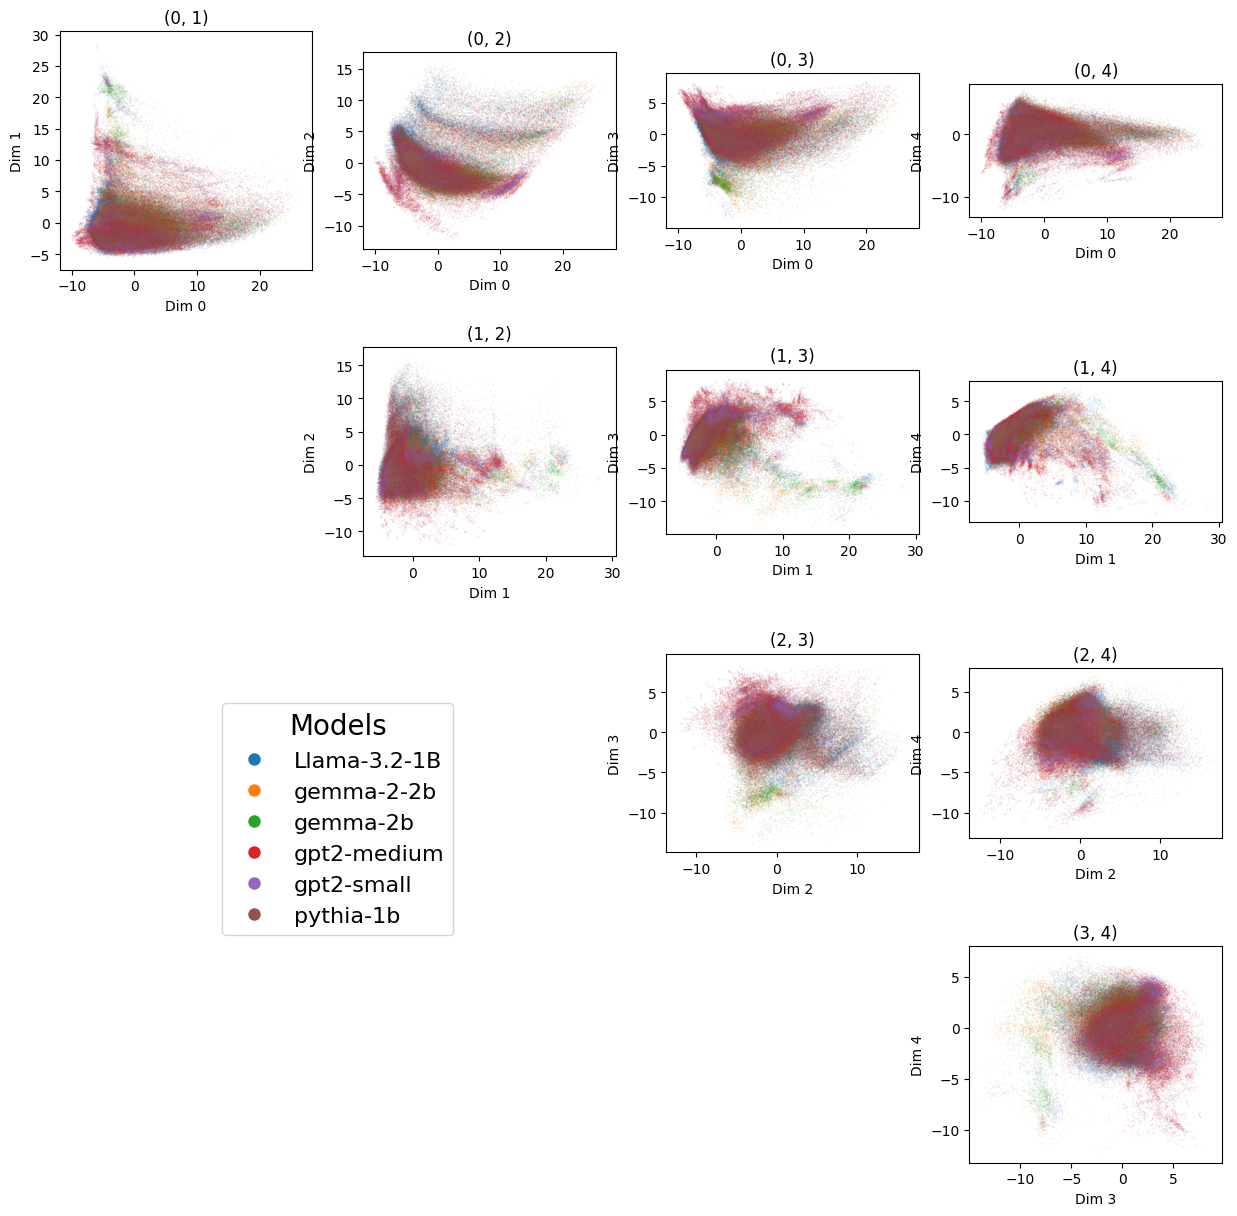

In [14]:
n_dims: int = 5
embed_fig, embed_ax = plt.subplots(
	n_dims - 1,
	n_dims - 1,
	figsize=(15, 15),
)
for i in range(0, n_dims - 1):
	for j in range(i + 1, n_dims):
		handles = plot_embedding(
			PCA_DATA,
			DATA_SCALED["activation.model"],
			(i, j),
			alpha=0.1,
			marker_size=1,
			title=f"({i}, {j})",
			ax=embed_ax[i, j - 1],
			do_legend=False,
		)
	for k in range(0, i):
		embed_ax[i, k].axis("off")
plt.legend(
	handles=handles,
	loc="lower left",
	bbox_to_anchor=(-3, 1),
	title="Models",
	fontsize=16,
	title_fontsize=20,
)
plt.savefig(PATH_FIGURES / "pca-all.png", dpi=500, bbox_inches="tight", pad_inches=0.01)

In [15]:
DATA_SCALED

activation.layer,activation.n_ctx,activation.head,feat.log.gram.col.hist.skewness,activation.model,feat.gram.row.hist.rms,feat.gram.skew.hist.linreg.intercept,feat.first_tok.energy,feat.log.gram.skew.hist.median,feat.first_tok.psd_total_power,feat.log.gram.row.hist.rms,feat.gram.col.hist.linreg.r2,feat.diag.psd_total_power,feat.log.gram.row.hist.psd_total_power,feat.log.gram.row.hist.linreg.slope,feat.log.gram.col.hist.mean,feat.diag.linreg.slope,feat.first_tok.linreg.slope,feat.gram.col.hist.median,feat.diag.kurtosis,feat.log.gram.col.hist.variance,activation.prompt,feat.log.gram.skew.hist.linreg.slope,feat.first_tok.L2_norm,feat.log.gram.skew.hist.variance,feat.gram.row.hist.mean,feat.gram.row.hist.psd_total_power,feat.gram.col.hist.linreg.intercept,feat.gram.skew.hist.linreg.slope,feat.first_tok.entropy,feat.gram.col.hist.rms,feat.first_tok.rms,feat.gram.row.hist.linreg.intercept,feat.gram.skew.hist.skewness,feat.gram.col.hist.psd_total_power,feat.first_tok.kurtosis,feat.log.gram.col.hist.rms,…,feat.gram.skew.hist.mean,feat.gram.skew.hist.linreg.r2,feat.log.gram.row.hist.entropy,feat.log.gram.col.hist.linreg.r2,feat.log.gram.row.hist.skewness,feat.log.gram.skew.hist.autocorr_lag1,feat.log.gram.skew.hist.psd_total_power,feat.log.gram.skew.hist.linreg.intercept,feat.diag.variance,feat.diag.linreg.r2,feat.log.gram.skew.hist.linreg.r2,feat.first_tok.mean,feat.first_tok.median,feat.diag.mean,feat.gram.col.hist.entropy,feat.gram.col.hist.linreg.slope,activation.cache_key,feat.gram.skew.hist.median,feat.log.gram.col.hist.linreg.intercept,feat.first_tok.autocorr_lag1,feat.log.gram.row.hist.linreg.r2,feat.gram.skew.hist.autocorr_lag1,feat.gram.skew.hist.rms,feat.log.gram.col.hist.autocorr_lag1,feat.diag.energy,feat.diag.autocorr_lag1,feat.log.gram.col.hist.entropy,feat.gram.col.hist.skewness,feat.log.gram.row.hist.variance,feat.gram.row.hist.entropy,feat.log.gram.row.hist.mean,feat.diag.entropy,feat.gram.skew.hist.variance,feat.log.gram.skew.hist.skewness,feat.first_tok.linreg.r2,feat.log.gram.skew.hist.mean,feat.log.gram.skew.hist.entropy
i64,i64,i64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,109,0,0.632443,"""gemma-2b""",-0.218839,-0.27878,-0.004741,1.680169,0.745983,0.787336,-0.743633,1.804951,-0.649108,-0.684034,-0.760119,0.551493,0.215031,-0.504639,-1.347009,0.932892,"""MjWkadUxH4Z5nfLEFtUc1w""",0.255678,-0.06103,-0.336878,-0.131938,-0.284212,-0.365125,0.091779,0.595424,0.754217,0.109091,-0.148865,1.106297,-0.467188,-0.355537,0.917424,…,-0.694588,-1.078767,-0.622777,-0.819866,0.45062,4.781122,-0.417044,-0.202521,1.695065,-1.059392,0.111103,0.0534,0.271778,0.188895,-0.9902,0.204488,"""blocks.0.attn.hook_pattern""",-0.478502,0.763975,-1.787147,-0.690024,-0.724955,0.95897,-1.545033,0.090481,-0.52873,-0.91877,0.735821,0.807477,1.588887,-0.683861,0.924762,0.9532,0.266012,-0.692938,-0.043862,-0.278865
0,109,1,0.639197,"""gemma-2b""",0.267115,-0.481843,0.003357,0.542598,2.473359,0.787336,-0.953984,-0.283993,-0.649108,-0.684034,-0.948187,0.452354,0.930868,-0.756184,0.476347,1.017918,"""MjWkadUxH4Z5nfLEFtUc1w""",0.298282,-0.054721,-0.333598,0.661144,-0.165753,-0.863056,0.215211,0.683147,1.214414,0.117301,0.610442,1.224311,-0.87707,-0.441883,0.993409,…,-1.063533,-1.31253,-0.622777,-0.887234,0.45062,-0.648657,-0.485568,-0.273348,-0.424506,-0.673847,-0.105551,-0.127905,-0.007139,-0.421555,-0.9902,0.639536,"""blocks.0.attn.hook_pattern""",-1.00518,0.932186,-2.060197,-0.690024,-1.136711,1.616427,0.433484,-0.236822,-0.439228,-0.91877,0.820295,0.807477,0.738432,-0.683861,-0.418394,1.822832,0.188764,-1.066142,-0.193015,-0.278865
0,109,2,0.610897,"""gemma-2b""",-0.294408,1.060029,0.048027,-0.045614,0.754772,0.781895,-0.074137,0.147722,-0.645812,-0.680203,-0.660535,0.333615,-0.29369,-0.767297,-1.255802,0.6